# Lunar Regional Data Struture Analysis
Default tile: WAC_GLOBAL_E0045S0450_100M with 212287 small craters (<10km)

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from LRO_data_class import getRegionalLunarData

/Users/none/miniconda3/envs/lunar_lro/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
tiles = [
    ('WAC_GLOBAL_E300S0450_100M'),
    ('WAC_GLOBAL_E300N1350_100M'),
    ('WAC_GLOBAL_E300S1350_100M'),
    ('WAC_GLOBAL_E300N2250_100M'),
    ('WAC_GLOBAL_E300S2250_100M'),
    ('WAC_GLOBAL_E300S3150_100M'),
    ('WAC_GLOBAL_E300N0450_100M'),
    ('WAC_GLOBAL_E300N3150_100M'),
]

allDataTiles = []

for tile in tiles:
    data = getRegionalLunarData(tile)
    allDataTiles.append((tile, data))

    print(f'\n{tile}')
    data.info()
    


WAC_GLOBAL_E300S0450_100M
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18194 entries, 0 to 18193
Columns: 27291 entries, 0 to 27290
dtypes: float32(27291)
memory usage: 1.8 GB

WAC_GLOBAL_E300N1350_100M
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18194 entries, 0 to 18193
Columns: 27291 entries, 0 to 27290
dtypes: float32(27291)
memory usage: 1.8 GB

WAC_GLOBAL_E300S1350_100M
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18194 entries, 0 to 18193
Columns: 27291 entries, 0 to 27290
dtypes: float32(27291)
memory usage: 1.8 GB

WAC_GLOBAL_E300N2250_100M
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18194 entries, 0 to 18193
Columns: 27291 entries, 0 to 27290
dtypes: float32(27291)
memory usage: 1.8 GB

WAC_GLOBAL_E300S2250_100M
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18194 entries, 0 to 18193
Columns: 27291 entries, 0 to 27290
dtypes: float32(27291)
memory usage: 1.8 GB

WAC_GLOBAL_E300S3150_100M
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18194 entries

In [3]:
summary = pd.DataFrame([{
    'tile': tile,
    'shape': dataTile.shape,
    'nulls': dataTile.isna().sum().sum(),
    'min': dataTile.values.min(),
    'max': dataTile.values.max(),
    'mean': dataTile.values.mean(),
    'std': dataTile.values.std()
} for tile, dataTile in allDataTiles])

display(summary)

,tile,shape,nulls,min,max,mean,std
0,WAC_GLOBAL_E300S0450_100M,"(18194, 27291)",0,-0.050797,0.470736,0.047326,0.018610
1,WAC_GLOBAL_E300N1350_100M,"(18194, 27291)",0,-0.002352,0.402926,0.056651,0.021023
2,WAC_GLOBAL_E300S1350_100M,"(18194, 27291)",0,-0.002678,0.562687,0.047924,0.018581
3,WAC_GLOBAL_E300N2250_100M,"(18194, 27291)",0,-0.036214,0.570455,0.054340,0.021250
4,WAC_GLOBAL_E300S2250_100M,"(18194, 27291)",0,-0.007670,0.398404,0.047254,0.019912
5,WAC_GLOBAL_E300S3150_100M,"(18194, 27291)",0,-0.018310,0.359843,0.044428,0.016791
6,WAC_GLOBAL_E300N0450_100M,"(18194, 27291)",0,-0.011826,0.395568,0.041002,0.017934
7,WAC_GLOBAL_E300N3150_100M,"(18194, 27291)",0,-0.002935,0.287448,0.033364,0.011798


## Image quality

In [4]:
allDataTiles255 = []

for tile, dataTile in  allDataTiles:
    data = dataTile.values
    dataFormat255 = ((data - data.min()) / (data.max() - data.min()) * 255).astype(np.uint8)
    allDataTiles255.append((tile, dataFormat255))


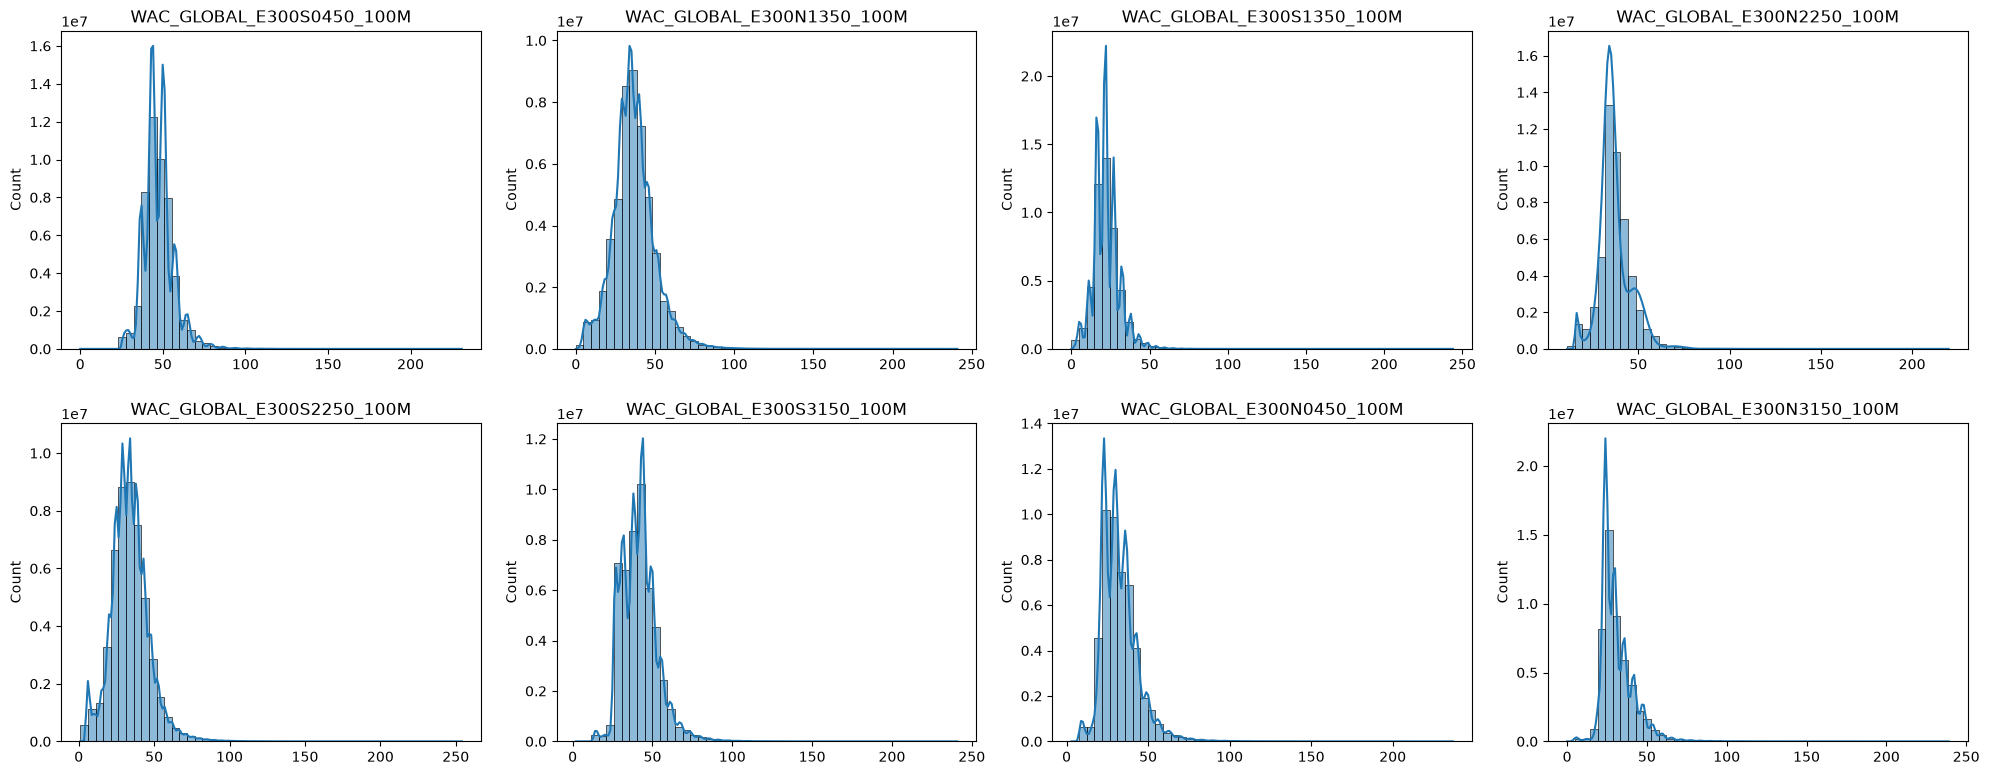

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for idx, (tile, data) in enumerate(allDataTiles255):
    row, col = divmod(idx, 4)
    sns.histplot(data.flatten()[::10], bins=50, kde=True, ax=axes[row][col])
    axes[row][col].set_title(tile)

plt.tight_layout()
plt.show()

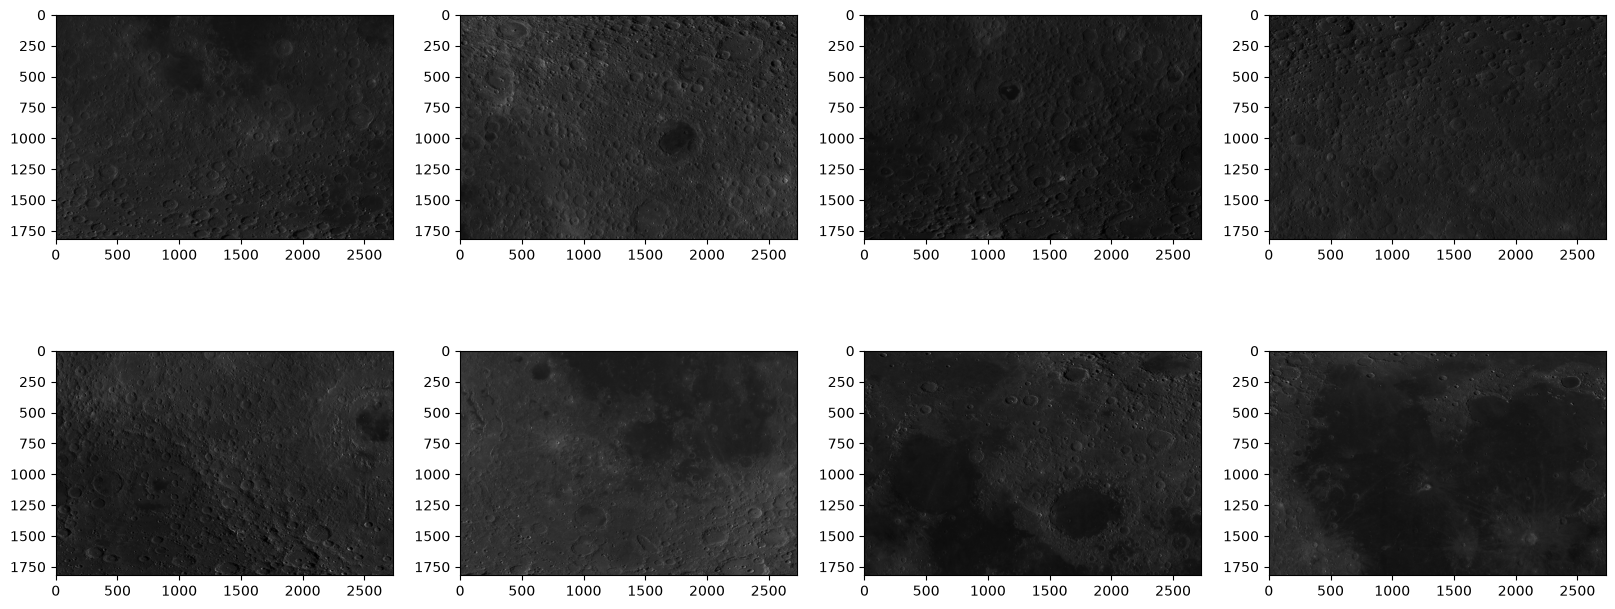

In [6]:
# two visible peaks: two distinct terrain types —> a mix of dark maria and brighter highlands.
# E300N1350, E300N2250, E300N3150

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for idx, (tile, data) in enumerate(allDataTiles255):
    row, col = divmod(idx, 4)
    axes[row][col].imshow(data[::10, ::10], cmap='gray')
